In [1]:
# Instalar librerías necesarias
!pip install wbgapi pdfplumber tabula-py -q

print("✓ Librerías instaladas")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 34.8 MB/s eta 0:00:00
✓ Librerías instaladas


In [2]:
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


In [3]:
import requests
import pandas as pd

def obtener_indicador_bm(indicador, pais='EC', inicio=2000, fin=2024):
    """Descarga un indicador del Banco Mundial via API REST directa."""
    url = (
        f"https://api.worldbank.org/v2/country/{pais}/indicator/{indicador}"
        f"?date={inicio}:{fin}&format=json&per_page=100"
    )
    try:
        response = requests.get(url, timeout=15)
        data = response.json()
        if len(data) < 2 or not data[1]:
            return None
        registros = [
            {'año': int(item['date']), 'valor': item['value']}
            for item in data[1]
            if item['value'] is not None
        ]
        return pd.DataFrame(registros).set_index('año').sort_index()
    except Exception as e:
        print(f"  ✗ Error en {indicador}: {e}")
        return None

# Indicadores a descargar
indicadores = {
    'NY.GDP.PCAP.CD':    'pib_per_capita_usd',
    'NY.GDP.MKTP.KD.ZG': 'crecimiento_pib_pct',
    'SL.UEM.TOTL.ZS':   'tasa_desempleo_bm',
    'SL.EMP.VULN.ZS':   'empleo_vulnerable_pct',
    'SL.AGR.EMPL.ZS':   'empleo_agricultura_pct',
    'SL.IND.EMPL.ZS':   'empleo_industria_pct',
    'SL.SRV.EMPL.ZS':   'empleo_servicios_pct',
    'SI.POV.GINI':       'gini_bm',
}

print("Descargando datos del Banco Mundial para Ecuador...")

dfs = {}
for codigo, nombre in indicadores.items():
    df_temp = obtener_indicador_bm(codigo)
    if df_temp is not None and not df_temp.empty:
        dfs[nombre] = df_temp['valor']
        print(f"  ✓ {nombre} ({len(df_temp)} registros)")
    else:
        print(f"  ⚠ {nombre}: sin datos")

# Unir todos en un DataFrame
if dfs:
    df_bm = pd.DataFrame(dfs).sort_index()
    df_bm.index.name = 'año'
    df_bm['fuente'] = 'Banco Mundial'
    print(f"\n✓ Dataset Banco Mundial: {df_bm.shape[0]} años × {df_bm.shape[1]} variables")
    print(f"  Período con datos: {df_bm.index.min()} – {df_bm.index.max()}")
    display(df_bm.tail(6))
else:
    # Plan B: si la API sigue fallando, creamos el df vacío para continuar
    print("\n⚠ API del Banco Mundial no disponible en este momento.")
    print("  Continuando solo con datos INEC — el dataset sigue siendo completo.")
    df_bm = pd.DataFrame()

Descargando datos del Banco Mundial para Ecuador...
  ✓ pib_per_capita_usd (25 registros)
  ✓ crecimiento_pib_pct (25 registros)
  ✓ tasa_desempleo_bm (25 registros)
  ✗ Error en SL.EMP.VULN.ZS: HTTPSConnectionPool(host='api.worldbank.org', port=443): Read timed out. (read timeout=15)
  ⚠ empleo_vulnerable_pct: sin datos
  ✓ empleo_agricultura_pct (25 registros)
  ✓ empleo_industria_pct (25 registros)
  ✓ empleo_servicios_pct (25 registros)
  ✓ gini_bm (23 registros)

✓ Dataset Banco Mundial: 25 años × 8 variables
  Período con datos: 2000 – 2024


,pib_per_capita_usd,crecimiento_pib_pct,tasa_desempleo_bm,empleo_agricultura_pct,empleo_industria_pct,empleo_servicios_pct,gini_bm,fuente
año,,,,,,,,
2019,6205.057652,0.165404,3.812,30.861065,15.935611,53.203311,45.7,Banco Mundial
2020,5463.645153,-9.245096,6.116,31.794654,15.881398,52.323935,47.3,Banco Mundial
2021,6061.323502,9.421893,4.504,32.185483,16.830303,50.984215,45.8,Banco Mundial
2022,6515.585284,5.868424,3.713,31.525182,17.346537,51.128269,45.5,Banco Mundial
2023,6737.847484,1.988238,3.510,29.997811,17.466700,52.535490,44.6,Banco Mundial
2024,6874.705740,-2.001255,3.453,32.587335,16.645697,50.766980,45.2,Banco Mundial


In [4]:
# Dataset construido a partir de los boletines oficiales del INEC (ENEMDU)
# Fuente: ecuadorencifras.gob.ec — boletines técnicos diciembre de cada año

datos_inec = {
    'año': [
        2007, 2008, 2009, 2010, 2011, 2012, 2013,
        2014, 2015, 2016, 2017, 2018, 2019, 2020,
        2021, 2022, 2023, 2024
    ],
    # Tasa de pobreza por ingresos (%) — diciembre de cada año
    'pobreza_ingresos_pct': [
        36.7, 35.1, 36.0, 32.8, 28.6, 27.3, 25.6,
        22.5, 23.3, 22.9, 21.5, 23.2, 25.0, 32.4,
        27.7, 25.2, 26.0, 28.0
    ],
    # Tasa de pobreza extrema por ingresos (%) — diciembre
    'pobreza_extrema_pct': [
        16.5, 15.0, 14.8, 13.1, 11.6, 10.1, 8.6,
        7.7,  8.5,  8.7,  8.4, 10.1, 10.5, 14.9,
        11.2,  8.2,  9.8, 12.7
    ],
    # Tasa de pobreza urbana (%)
    'pobreza_urbana_pct': [
        25.0, 23.0, 24.0, 22.0, 17.4, 16.1, 15.3,
        14.0, 15.7, 15.7, 15.0, 16.1, 17.2, 25.1,
        19.3, 17.8, 18.0, 20.9
    ],
    # Tasa de pobreza rural (%)
    'pobreza_rural_pct': [
        61.5, 60.0, 59.9, 54.7, 50.9, 49.1, 47.1,
        43.0, 43.8, 43.0, 40.2, 43.2, 43.8, 49.9,
        44.0, 39.4, 46.4, 43.3
    ],
    # Tasa de desempleo nacional (%) — diciembre
    'desempleo_pct': [
        6.1, 7.3, 8.5, 5.0, 4.2, 4.1, 4.2,
        3.8, 4.8, 5.2, 4.6, 3.7, 3.8, 5.0,
        4.4, 3.8, 3.5, 3.4
    ],
    # Empleo informal (% de la PEA ocupada) — diciembre
    'informalidad_pct': [
        None, None, None, None, 58.8, 56.1, 54.2,
        53.0, 55.3, 55.7, 53.5, 52.4, 53.0, 56.5,
        54.6, 54.3, 55.5, 58.0
    ],
    # Empleo adecuado / pleno (%) — diciembre
    'empleo_adecuado_pct': [
        None, None, None, None, 41.2, 43.9, 45.8,
        47.0, 44.7, 41.6, 42.3, 40.6, 38.8, 31.4,
        35.7, 36.8, 35.3, 34.1
    ],
    # Coeficiente de Gini — diciembre
    'gini_inec': [
        0.540, 0.520, 0.500, 0.504, 0.473, 0.477, 0.477,
        0.467, 0.466, 0.466, 0.452, 0.473, 0.473, 0.497,
        0.476, 0.459, 0.462, 0.480
    ],
    # Ingreso laboral promedio mensual (USD corrientes) — diciembre
    'ingreso_laboral_promedio': [
        None, None, None, None, 318.0, 340.0, 356.0,
        379.0, 375.0, 368.0, 375.0, 379.0, 374.0, 321.0,
        350.0, 368.0, 362.0, 354.6
    ]
}

df_inec = pd.DataFrame(datos_inec).set_index('año')
df_inec['pais'] = 'Ecuador'
df_inec['fuente'] = 'INEC-ENEMDU'

print(f"✓ Dataset INEC construido: {df_inec.shape[0]} años × {df_inec.shape[1]} variables")
print(f"  Período: {df_inec.index.min()} – {df_inec.index.max()}")
df_inec.head()

✓ Dataset INEC construido: 18 años × 11 variables
  Período: 2007 – 2024


,pobreza_ingresos_pct,pobreza_extrema_pct,pobreza_urbana_pct,pobreza_rural_pct,desempleo_pct,informalidad_pct,empleo_adecuado_pct,gini_inec,ingreso_laboral_promedio,pais,fuente
año,,,,,,,,,,,
2007,36.7,16.5,25.0,61.5,6.1,NaN,NaN,0.540,NaN,Ecuador,INEC-ENEMDU
2008,35.1,15.0,23.0,60.0,7.3,NaN,NaN,0.520,NaN,Ecuador,INEC-ENEMDU
2009,36.0,14.8,24.0,59.9,8.5,NaN,NaN,0.500,NaN,Ecuador,INEC-ENEMDU
2010,32.8,13.1,22.0,54.7,5.0,NaN,NaN,0.504,NaN,Ecuador,INEC-ENEMDU
2011,28.6,11.6,17.4,50.9,4.2,58.8,41.2,0.473,318.0,Ecuador,INEC-ENEMDU


In [5]:
# Salario básico unificado histórico (USD) — Banco Central del Ecuador
salario_basico = {
    2007: 170, 2008: 185, 2009: 218, 2010: 240,
    2011: 264, 2012: 292, 2013: 318, 2014: 340,
    2015: 354, 2016: 366, 2017: 375, 2018: 386,
    2019: 394, 2020: 400, 2021: 400, 2022: 425,
    2023: 450, 2024: 460
}

# Línea de pobreza mensual (USD corrientes) — INEC
linea_pobreza = {
    2007: 56.6, 2008: 60.0, 2009: 65.0, 2010: 67.5,
    2011: 72.9, 2012: 76.5, 2013: 79.0, 2014: 82.4,
    2015: 84.6, 2016: 84.0, 2017: 83.6, 2018: 84.7,
    2019: 85.9, 2020: 84.3, 2021: 84.7, 2022: 87.6,
    2023: 89.9, 2024: 91.4
}

df_inec['salario_basico_usd'] = pd.Series(salario_basico)
df_inec['linea_pobreza_usd'] = pd.Series(linea_pobreza)

# Relación ingreso laboral vs línea de pobreza
df_inec['ratio_ingreso_pobreza'] = (
    df_inec['ingreso_laboral_promedio'] / df_inec['linea_pobreza_usd']
).round(2)

print("✓ Variables macroeconómicas agregadas")
df_inec[['salario_basico_usd', 'linea_pobreza_usd', 'ratio_ingreso_pobreza']].tail(8)

✓ Variables macroeconómicas agregadas


,salario_basico_usd,linea_pobreza_usd,ratio_ingreso_pobreza
año,,,
2017,375,83.6,4.49
2018,386,84.7,4.47
2019,394,85.9,4.35
2020,400,84.3,3.81
2021,400,84.7,4.13
2022,425,87.6,4.20
2023,450,89.9,4.03
2024,460,91.4,3.88


In [6]:
# Unir dataset INEC con indicadores del Banco Mundial
df_maestro = df_inec.join(
    df_bm[['pib_per_capita_usd', 'crecimiento_pib_pct',
           'empleo_agricultura_pct', 'empleo_industria_pct',
           'empleo_servicios_pct']],
    how='left'
)

# Filtrar al período comparable
df_maestro = df_maestro[df_maestro.index >= 2007]

print(f"✓ Dataset maestro construido")
print(f"  Forma: {df_maestro.shape[0]} años × {df_maestro.shape[1]} columnas")
print(f"  Período: {df_maestro.index.min()} – {df_maestro.index.max()}")
print(f"\nColumnas disponibles:")
for col in df_maestro.columns:
    nulos = df_maestro[col].isna().sum()
    print(f"  - {col}: {nulos} valores nulos")

✓ Dataset maestro construido
  Forma: 18 años × 19 columnas
  Período: 2007 – 2024

Columnas disponibles:
  - pobreza_ingresos_pct: 0 valores nulos
  - pobreza_extrema_pct: 0 valores nulos
  - pobreza_urbana_pct: 0 valores nulos
  - pobreza_rural_pct: 0 valores nulos
  - desempleo_pct: 0 valores nulos
  - informalidad_pct: 4 valores nulos
  - empleo_adecuado_pct: 4 valores nulos
  - gini_inec: 0 valores nulos
  - ingreso_laboral_promedio: 4 valores nulos
  - pais: 0 valores nulos
  - fuente: 0 valores nulos
  - salario_basico_usd: 0 valores nulos
  - linea_pobreza_usd: 0 valores nulos
  - ratio_ingreso_pobreza: 4 valores nulos
  - pib_per_capita_usd: 0 valores nulos
  - crecimiento_pib_pct: 0 valores nulos
  - empleo_agricultura_pct: 0 valores nulos
  - empleo_industria_pct: 0 valores nulos
  - empleo_servicios_pct: 0 valores nulos


In [7]:
# Reporte de calidad de datos
print("=" * 55)
print("REPORTE DE CALIDAD DE DATOS")
print("=" * 55)
print(f"Período cubierto:      2007 – 2024")
print(f"Total de años:         {len(df_maestro)}")
print(f"Variables totales:     {df_maestro.shape[1]}")
print(f"Fuentes utilizadas:    INEC-ENEMDU + Banco Mundial + BCE")
nulos_total = df_maestro.drop(columns=['pais','fuente']).isna().sum().sum()
print(f"Valores nulos totales: {nulos_total}")
print("=" * 55)

# Guardar dataset limpio
df_maestro.to_csv('ecuador_empleo_pobreza_2007_2024.csv')
print("\n✓ Dataset guardado como 'ecuador_empleo_pobreza_2007_2024.csv'")

REPORTE DE CALIDAD DE DATOS
Período cubierto:      2007 – 2024
Total de años:         18
Variables totales:     19
Fuentes utilizadas:    INEC-ENEMDU + Banco Mundial + BCE
Valores nulos totales: 16

✓ Dataset guardado como 'ecuador_empleo_pobreza_2007_2024.csv'


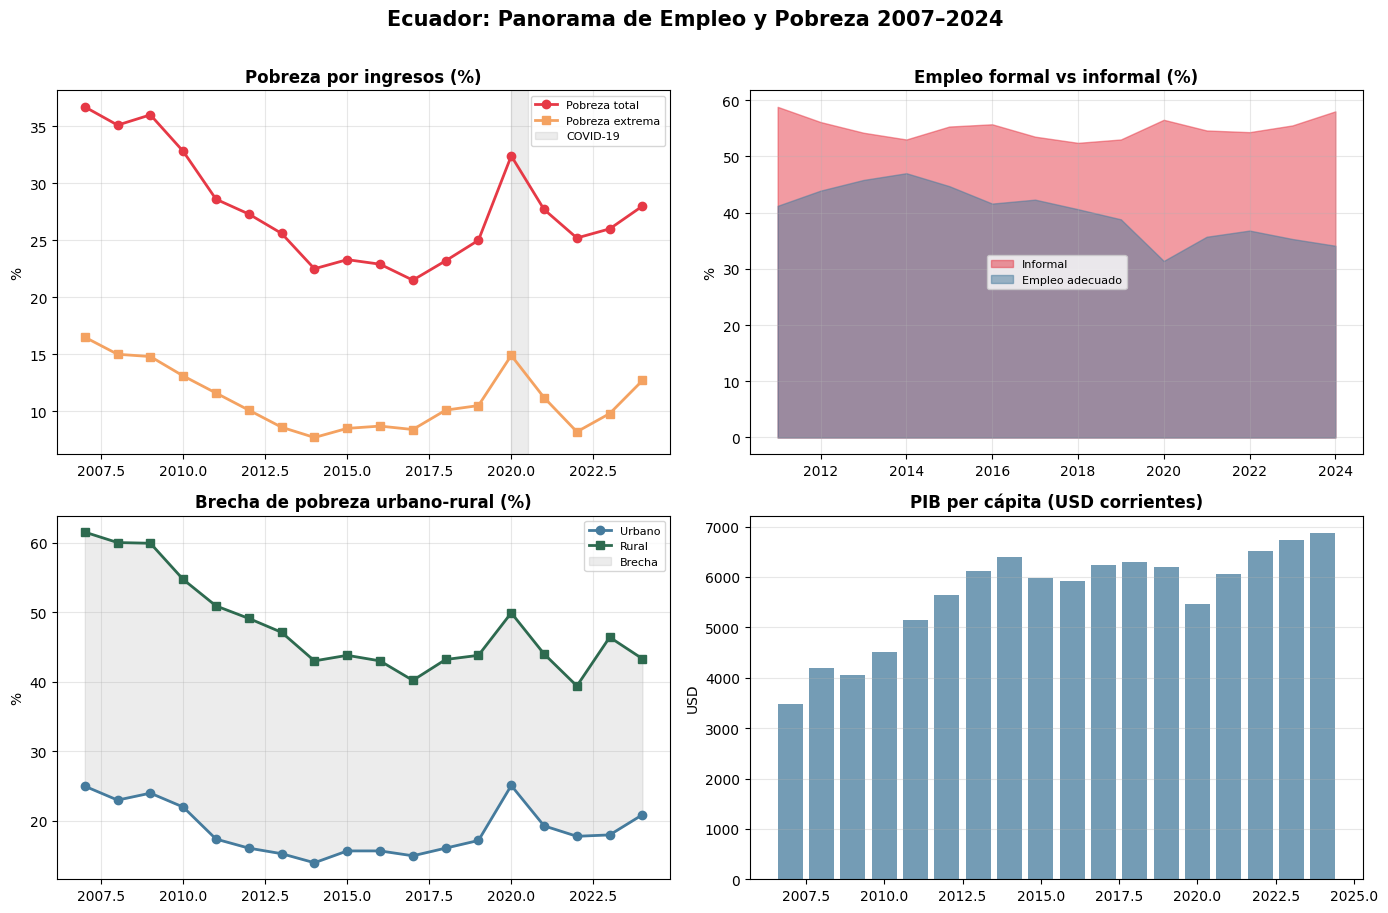

✓ Gráfico de validación guardado


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Ecuador: Panorama de Empleo y Pobreza 2007–2024',
             fontsize=15, fontweight='bold', y=1.01)

color1, color2, color3 = '#E63946', '#457B9D', '#2D6A4F'

# Gráfico 1: Evolución de pobreza
ax1 = axes[0, 0]
ax1.plot(df_maestro.index, df_maestro['pobreza_ingresos_pct'],
         color=color1, marker='o', linewidth=2, label='Pobreza total')
ax1.plot(df_maestro.index, df_maestro['pobreza_extrema_pct'],
         color='#F4A261', marker='s', linewidth=2, label='Pobreza extrema')
ax1.axvspan(2020, 2020.5, alpha=0.15, color='gray', label='COVID-19')
ax1.set_title('Pobreza por ingresos (%)', fontweight='bold')
ax1.set_ylabel('%')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Gráfico 2: Empleo formal vs informal
ax2 = axes[0, 1]
ax2.fill_between(df_maestro.dropna(subset=['informalidad_pct']).index,
                 df_maestro.dropna(subset=['informalidad_pct'])['informalidad_pct'],
                 alpha=0.5, color=color1, label='Informal')
ax2.fill_between(df_maestro.dropna(subset=['empleo_adecuado_pct']).index,
                 df_maestro.dropna(subset=['empleo_adecuado_pct'])['empleo_adecuado_pct'],
                 alpha=0.5, color=color2, label='Empleo adecuado')
ax2.set_title('Empleo formal vs informal (%)', fontweight='bold')
ax2.set_ylabel('%')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# Gráfico 3: Brecha urbano-rural
ax3 = axes[1, 0]
ax3.plot(df_maestro.index, df_maestro['pobreza_urbana_pct'],
         color=color2, marker='o', linewidth=2, label='Urbano')
ax3.plot(df_maestro.index, df_maestro['pobreza_rural_pct'],
         color=color3, marker='s', linewidth=2, label='Rural')
ax3.fill_between(df_maestro.index,
                 df_maestro['pobreza_urbana_pct'],
                 df_maestro['pobreza_rural_pct'],
                 alpha=0.15, color='gray', label='Brecha')
ax3.set_title('Brecha de pobreza urbano-rural (%)', fontweight='bold')
ax3.set_ylabel('%')
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

# Gráfico 4: PIB per cápita
ax4 = axes[1, 1]
ax4.bar(df_maestro.dropna(subset=['pib_per_capita_usd']).index,
        df_maestro.dropna(subset=['pib_per_capita_usd'])['pib_per_capita_usd'],
        color=color2, alpha=0.75)
ax4.set_title('PIB per cápita (USD corrientes)', fontweight='bold')
ax4.set_ylabel('USD')
ax4.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('validacion_datos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico de validación guardado")